Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


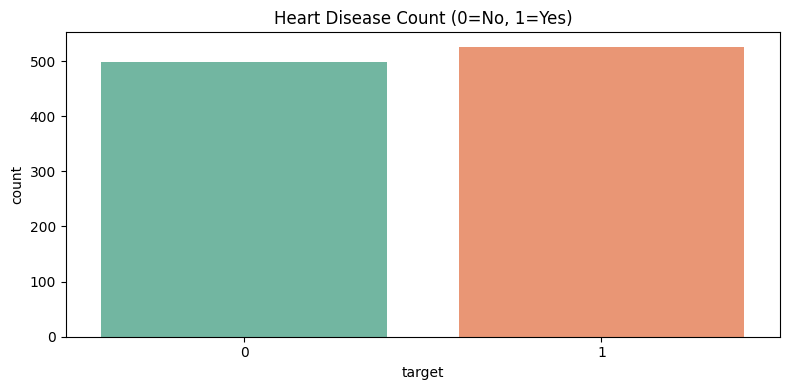

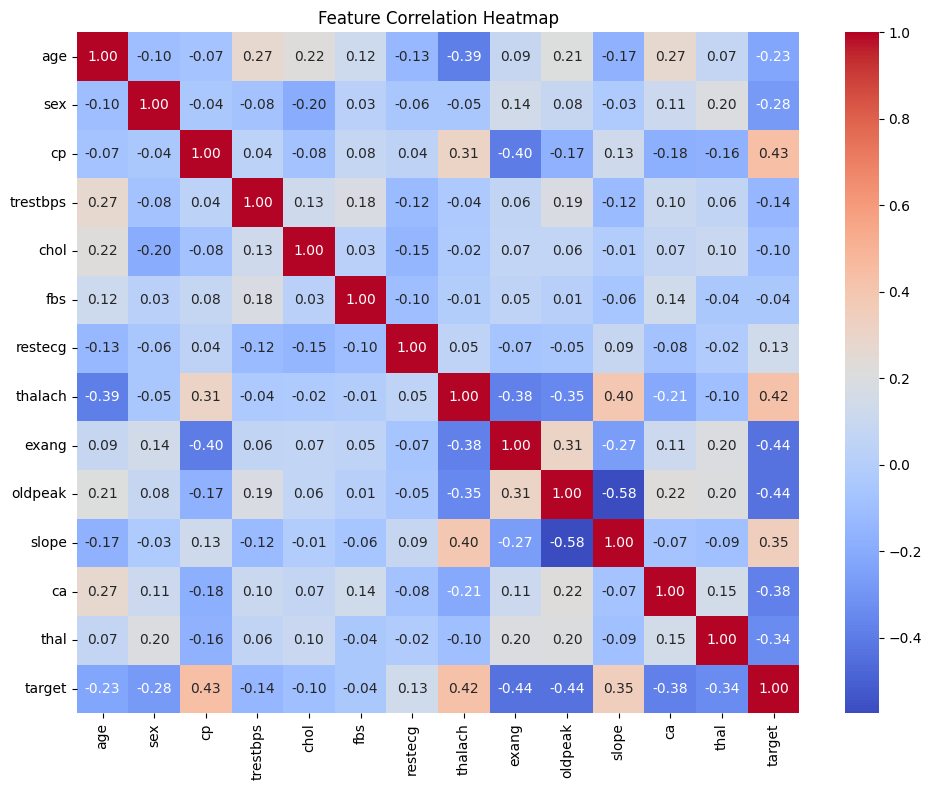


✅ Accuracy: 0.7951219512195122


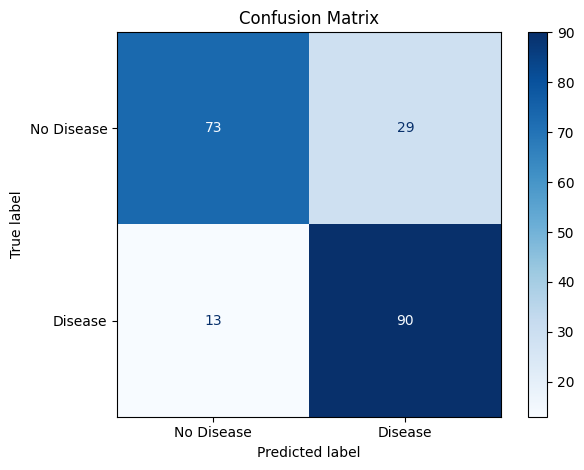

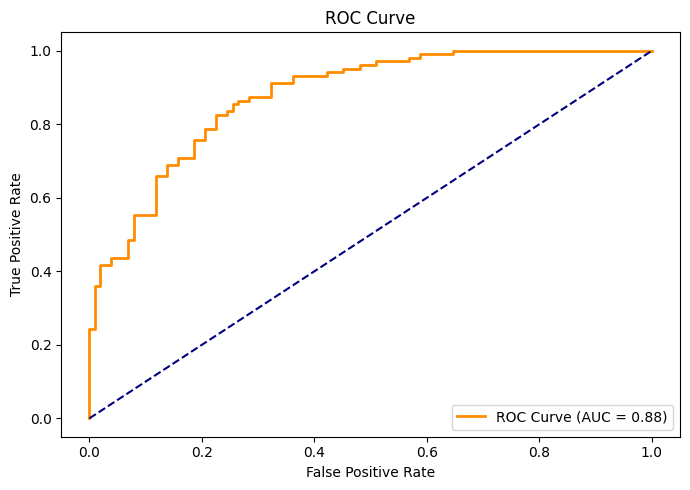

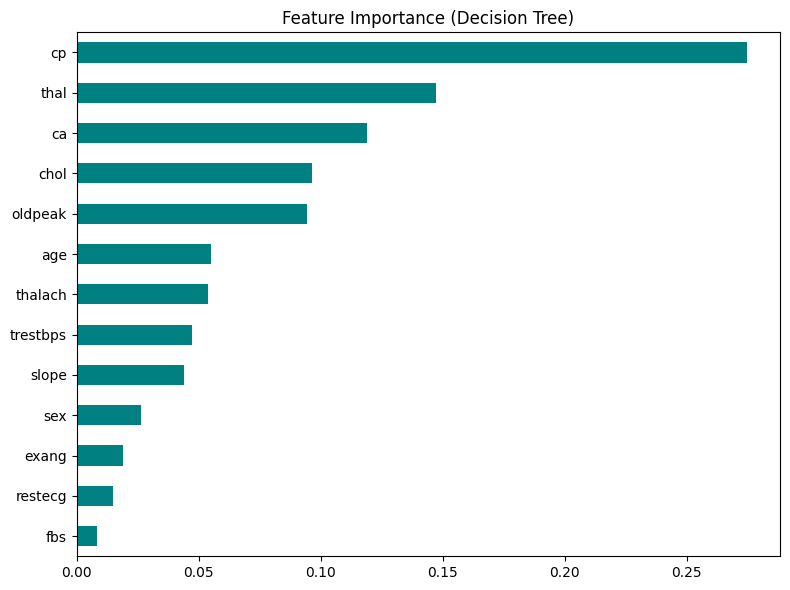


✅ Task 3 Complete!


In [1]:
# --- 1. Imports ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# --- 2. Load Dataset ---
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['target'].value_counts())

# --- 3. EDA ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Heart Disease Count (0=No, 1=Yes)')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# --- 4. Preprocessing ---
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5. Train Logistic Regression ---
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))

# --- 6. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# --- 7. ROC Curve ---
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# --- 8. Feature Importance (using Decision Tree) ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\n✅ Task 3 Complete!")